# Example: Application of Time-Series Models to S&P 500 Exposure (SPY Returns)

Notebook 05 compared fixed empirical and parametric distributions with future returns. Here I ask whether modeling temporal dependence and changing volatility improves that description and its downside-risk predictions. The sequence is the same: observed data, fitted models, downside risk and out-of-sample evaluation.

The example adapts Tonellato’s S&P 500 practical application to Notebook 05’s adjusted SPY data and longer period: fit a mean model, inspect its residuals for ARCH effects, fit mean and variance jointly, check standardized residuals and forecast. Notebooks 06–07 provide the process foundations; Notebooks 08–10 provide the models and diagnostics. This notebook applies those tools rather than introducing new model classes.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import pacf
from arch import arch_model
from finstats.nonparametric import qq_data
from finstats.timeseries.diagnostics import acf, ljung_box, mcleod_li, standardized_residuals
from finstats.timeseries.volatility import garch11_unconditional_variance, garch11_forecast
from finstats.timeseries.forecasting import forecast_rmse, forecast_mae, forecast_mse

# Styling only; calculations use the library functions introduced earlier.
def dependence_panel(ax, values, title, nobs):
    ax.vlines(np.arange(len(values)),0,values,color="C0",linewidth=1.2)
    ax.axhline(0,color="0.6",linewidth=.8)
    bound = stats.norm.ppf(.975)/np.sqrt(nobs)
    ax.hlines([bound,-bound],.5,len(values)-.5,color="0.35",linestyle="--",linewidth=.9)
    ax.set(xlabel="Lag",ylabel="Sample correlation",title=title)
from statsmodels.tsa.stattools import adfuller
from arch.univariate import Normal, StudentsT
from finstats.risk import gaussian_var, gaussian_es, student_t_var, student_t_es

## 1. Data and Return Construction

I use the same saved adjusted SPY prices as Notebook 05. SPY provides S&P 500 exposure; adjusted prices account for distributions and corporate actions. This adapts the professor’s price-index/log-return example to a common dataset for comparing fixed and conditional models.

Daily simple returns are $R_t=100(P_t/P_{t-1}-1)$, in percentage points, and relative losses are $L_t=-R_t$. These are the same definitions used in Notebook 05. Dividends are not added again to adjusted prices.

### Training and Out-of-Sample Evaluation

Estimate and select models using 2017–2022 only, then evaluate on 2023–2025 without re-estimating parameters. The first 24 future observations illustrate forecasts from one origin. A rolling one-step evaluation uses the entire out-of-sample period; previously observed returns may update the model state before predicting the next observation. No future return enters its own forecast.

Prices: 2017-01-03–2025-12-31, n=2262
Training returns: 2017-01-04–2022-12-30, n=1509
Out-of-sample returns: 2023-01-03–2025-12-31, n=752


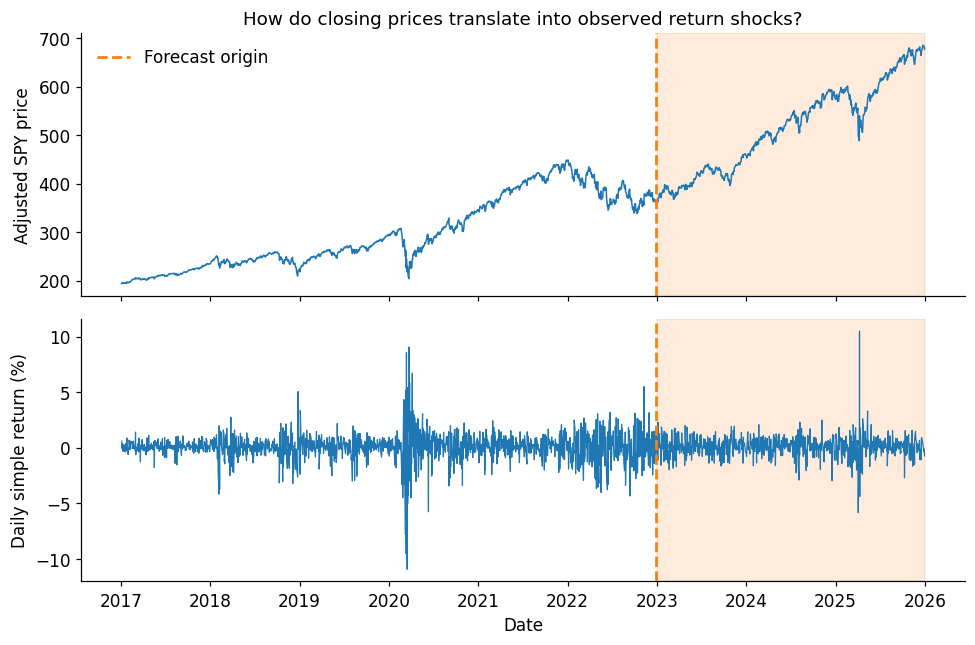

In [2]:
price_frame = pd.read_csv(repository / "data/spy_adjusted_prices_2017_2025.csv",parse_dates=["Date"])
assert price_frame.Date.is_monotonic_increasing and price_frame.Date.is_unique
assert np.isfinite(price_frame.AdjustedClose).all() and (price_frame.AdjustedClose>0).all()
prices = price_frame.set_index("Date").AdjustedClose
returns = (100*prices.pct_change(fill_method=None)).iloc[1:].rename("return")
assert np.isfinite(returns).all()
train = returns.loc[:"2022-12-31"]
test = returns.loc["2023-01-01":]
assert len(test)>700 and train.index.max()<test.index.min()
print(f"Prices: {prices.index.min().date()}–{prices.index.max().date()}, n={len(prices)}")
print(f"Training returns: {train.index.min().date()}–{train.index.max().date()}, n={len(train)}")
print(f"Out-of-sample returns: {test.index.min().date()}–{test.index.max().date()}, n={len(test)}")
fig, axes = plt.subplots(2,1,figsize=(9,6),sharex=True)
axes[0].plot(prices.index,prices,linewidth=1);axes[0].set(ylabel="Adjusted SPY price",title="How do closing prices translate into observed return shocks?")
axes[1].plot(returns.index,returns,linewidth=.8);axes[1].set(xlabel="Date",ylabel="Daily simple return (%)")
for ax in axes:
    ax.axvspan(test.index.min(),test.index.max(),color="C1",alpha=.15)
    ax.axvline(train.index.max(),color="C1",linestyle="--",label="Forecast origin")
axes[0].legend();fig.tight_layout();plt.show()

## 2. Empirical Properties

### Empirical Distribution and Moments

As in Notebooks 01, 04 and 05, these quantities describe one finite sample. The histogram and KDE summarize the distribution while discarding temporal ordering.

,n,mean (%),SD (%),skewness,raw kurtosis
0,1509,0.0499,1.25145,-0.57468,15.53046


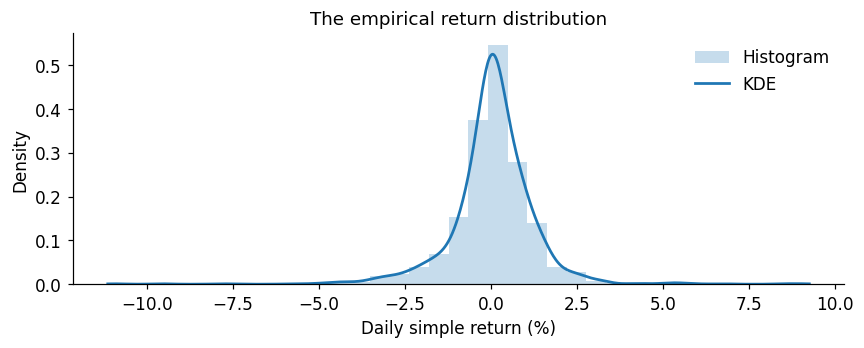

In [3]:
descriptive_table = pd.DataFrame([{"n":len(train),"mean (%)":sample_mean(train),"SD (%)":sample_standard_deviation(train),"skewness":sample_skewness(train),"raw kurtosis":sample_kurtosis(train)}])
display(descriptive_table.round(5))
train_mu, train_sd = sample_mean(train),sample_standard_deviation(train)
return_grid = np.linspace(train.min()-.2,train.max()+.2,801)
fig, ax = plt.subplots(figsize=(8,3.3))
ax.hist(train,bins=35,density=True,alpha=.25,color="C0",label="Histogram")
ax.plot(return_grid,stats.gaussian_kde(train)(return_grid),color="C0",label="KDE")
ax.set(xlabel="Daily simple return (%)",ylabel="Density",title="The empirical return distribution")
ax.legend();fig.tight_layout();plt.show()

### Temporal Dependence and Stationarity

The return ACF/PACF describe linear dependence; the squared-return ACF describes dependence in magnitudes. The ADF test has a unit-root null. Rejecting that null is evidence against a unit root under its specification, not proof of stationarity or ergodicity. Log adjusted prices include an intercept and trend; returns include an intercept.

Dashed lines show approximate pointwise 95% white-noise reference bounds $\pm1.96/\sqrt{n}$ around zero, using the estimation-sample size. They are not simultaneous confidence bounds. For squared returns, the reference is a diagnostic approximation requiring suitable moments, rather than a model-specific confidence interval.

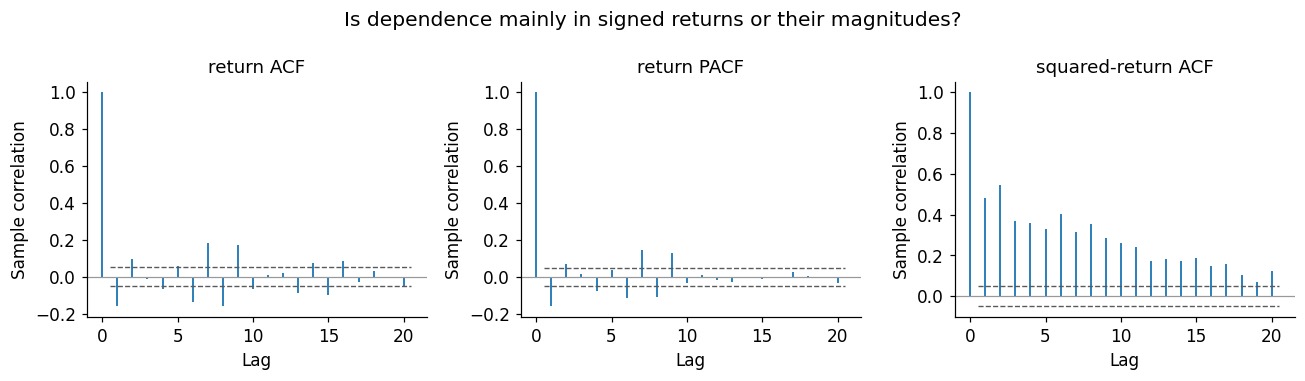

,Series,Deterministic terms,ADF statistic,p-value,Augmentation lags,Observations
0,Log price,ct,-2.560977,2.981756e-01,9,1500
1,Return,c,-12.025525,2.955195e-22,8,1500


In [4]:
fig, axes = plt.subplots(1,3,figsize=(12,3.5))
dependence_panel(axes[0],acf(train,20),"return ACF",len(train))
dependence_panel(axes[1],pacf(train,nlags=20,method="ywm"),"return PACF",len(train))
dependence_panel(axes[2],acf(train**2,20),"squared-return ACF",len(train))
fig.suptitle("Is dependence mainly in signed returns or their magnitudes?")
fig.tight_layout();plt.show()
stationarity_rows = []
training_log_prices = np.log(prices.loc[:train.index.max()]).to_numpy()
for label, values, specification in (("Log price", training_log_prices, "ct"), ("Return", train.to_numpy(), "c")):
    statistic, p_value, used_lag, nobs, critical_values, _ = adfuller(values, regression=specification, autolag="AIC")
    stationarity_rows.append({"Series":label, "Deterministic terms":specification, "ADF statistic":statistic, "p-value":p_value, "Augmentation lags":used_lag, "Observations":nobs})
display(pd.DataFrame(stationarity_rows))

## 3. Parametric Models and Estimation

### Identify and Fit the Conditional Mean

The course uses automatic ARIMA selection on log prices and subsequently an ARMA(1,2) mean for returns. Here a bounded automatic AIC comparison selects an AR order from 0, 1 and 2 for the returns. It is a restricted search, not a reproduction of R’s `auto.arima` algorithm.

This deliberate Python simplification permits genuine joint estimation with the mature `arch` package, whose built-in mean models support AR lags but not MA terms. AR(0) denotes a constant mean. A Gaussian working likelihood does not establish Gaussian innovations.

In [5]:
mean_models = {}
for p in [0,1,2]:
    fit = ARIMA(train.to_numpy(),order=(p,0,0),trend="c").fit()
    if not fit.mle_retvals.get("converged",True): raise RuntimeError(f"Mean candidate AR({p}) did not converge")
    mean_models[p] = fit
mean_comparison = pd.DataFrame([{"AR order":p,"log-likelihood":fit.llf,"AIC":fit.aic,"BIC":fit.bic} for p,fit in mean_models.items()])
display(mean_comparison.round(4))
selected_p = min(mean_models,key=lambda p:mean_models[p].aic)
mean_fit = mean_models[selected_p]
print(f"Selected mean within prespecified set: AR({selected_p})")
display(pd.DataFrame({"estimate":mean_fit.params,"standard error":mean_fit.bse},index=mean_fit.param_names).round(6))

,AR order,log-likelihood,AIC,BIC
0,0,-2479.1557,4962.3114,4972.9498
1,1,-2459.5033,4925.0065,4940.9642
2,2,-2455.5333,4919.0666,4940.3434


Selected mean within prespecified set: AR(2)


,estimate,standard error
const,0.049942,0.031721
ar.L1,-0.148701,0.011391
ar.L2,0.072456,0.010552
sigma2,1.516804,0.022707


### Residual Diagnostics and ARCH Effects

Following the course, inspect residuals before fitting volatility. Residual serial correlation suggests an inadequate mean model; dependence in squared residuals motivates conditional variance. Ljung–Box and McLeod–Li summarize these separate questions, with approximate post-estimation p-values. Neither test proves independence or uniquely identifies a GARCH order.

statistic  p_value  df  lags  nobs
Series                                                  
Residuals         0    93.86756      0.0   8    10  1507
                  1   123.55326      0.0  18    20  1507
Squared residuals 0  1620.48654      0.0  10    10  1507
                  1  1979.02687      0.0  20    20  1507

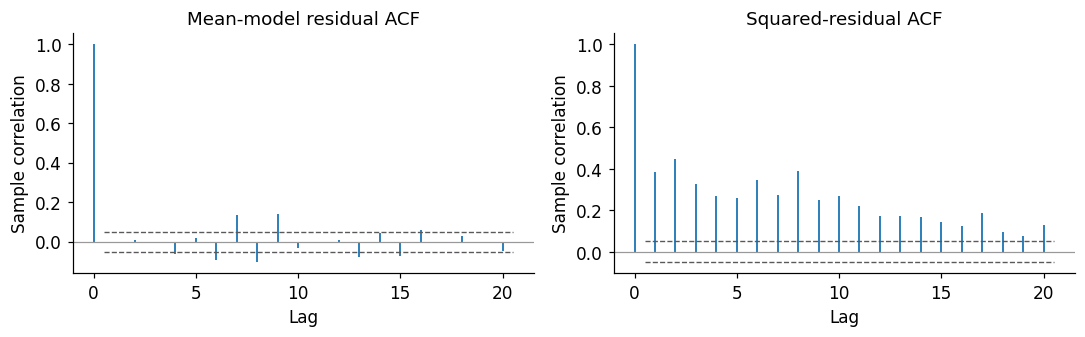

In [6]:
mean_residuals = np.asarray(mean_fit.resid)[2:]
mean_diagnostics = pd.DataFrame([ljung_box(mean_residuals,h,model_df=selected_p) for h in [10,20]])
arch_diagnostics = pd.DataFrame([mcleod_li(mean_residuals,h) for h in [10,20]])
display(pd.concat({"Residuals":mean_diagnostics,"Squared residuals":arch_diagnostics},names=["Series"]).round(5))
fig, axes = plt.subplots(1,2,figsize=(10,3.2))
dependence_panel(axes[0],acf(mean_residuals,20),"Mean-model residual ACF",len(mean_residuals))
dependence_panel(axes[1],acf(mean_residuals**2,20),"Squared-residual ACF",len(mean_residuals))
fig.tight_layout();plt.show()

### Joint Mean and Volatility Estimation

Fit AR–GARCH(1,1) jointly under Gaussian and standardized Student-t innovations, using the same observations. GARCH(1,1) is the course’s practical variance specification. Parameters have numerical MLEs; convergence does not certify a global optimum.

The course’s heavier-tailed alternative is **skewed** Student-t. Here I retain the symmetric Student-t developed in Notebooks 09–10; the difference is explicit and residual asymmetry remains a possible limitation.

In [7]:
gaussian_fit = arch_model(train,mean="AR",lags=selected_p,vol="GARCH",p=1,q=1,dist="normal",rescale=False,hold_back=2).fit(disp="off",update_freq=0)
assert gaussian_fit.convergence_flag==0
student_fit = arch_model(train,mean="AR",lags=selected_p,vol="GARCH",p=1,q=1,dist="t",rescale=False,hold_back=2).fit(disp="off",update_freq=0)
assert student_fit.convergence_flag==0
garch_comparison = pd.DataFrame([{"innovation":label,"nobs":fit.nobs,"log-likelihood":fit.loglikelihood,"AIC":fit.aic,"BIC":fit.bic,"df":fit.params.get("nu",np.nan)} for label,fit in [("Gaussian",gaussian_fit),("Student-t",student_fit)]])
display(garch_comparison.round(5))
final_fit = min([gaussian_fit,student_fit],key=lambda fit:fit.aic)
final_label = "Student-t" if final_fit is student_fit else "Gaussian"
print("Preferred within this comparison:",final_label)


,innovation,nobs,log-likelihood,AIC,BIC,df
0,Gaussian,1507,-1984.33027,3980.66055,4012.56780,NaN
1,Student-t,1507,-1931.33477,3876.66955,3913.89468,5.6788


Preferred within this comparison: Student-t


### Standardized Residuals and Innovation Quantiles

Check the chosen model’s standardized residuals and their squares, then compare both candidate densities using QQ plots as in Notebook 04. A satisfactory QQ plot addresses the marginal innovation density, not temporal independence. Squared-residual tests require appropriate moment assumptions; their p-values are omitted when fitted Student-t degrees of freedom do not exceed four.

,series,statistic,p_value,df,lags,nobs
0,standardized,10.225383,0.249562,8,10,1507
1,squared standardized,9.417032,0.493035,10,10,1507
2,standardized,15.770148,0.608585,18,20,1507
3,squared standardized,13.627907,0.848850,20,20,1507


,estimate,robust SE
Const,0.114277,0.016932
return[1],-0.059262,0.026274
return[2],-0.009430,0.028250
omega,0.017202,0.006043
alpha[1],0.181674,0.028920
beta[1],0.818326,0.027039
nu,5.678802,0.745269


Preferred persistence=1.000000
No reliable finite long-run variance: the fit is at the numerical unit-persistence boundary.


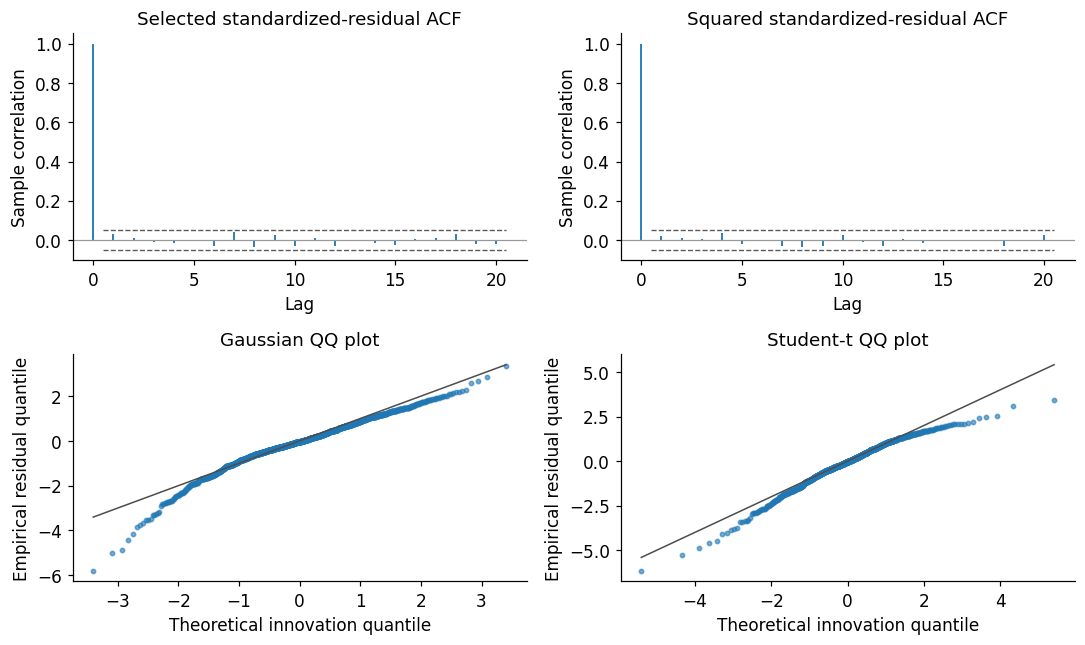

In [8]:
valid_final = np.isfinite(final_fit.resid)&np.isfinite(final_fit.conditional_volatility)
final_residuals = np.asarray(final_fit.resid)[valid_final]
final_variances = np.asarray(final_fit.conditional_volatility)[valid_final]**2
final_standardized = standardized_residuals(final_residuals,np.sqrt(final_variances))
final_df = final_fit.params.get("nu",np.inf)
final_diagnostic_rows = []
for h in [10,20]:
    final_diagnostic_rows.append({"series":"standardized",**ljung_box(final_standardized,h,model_df=selected_p)})
    squared_screen = mcleod_li(final_standardized,h)
    if final_df<=4: squared_screen["p_value"]=np.nan
    final_diagnostic_rows.append({"series":"squared standardized",**squared_screen})
final_diagnostics = pd.DataFrame(final_diagnostic_rows)
display(final_diagnostics.round(6))
if final_df<=4: print("Squared-screen p-values omitted: fitted innovations have no finite fourth moment.")
display(pd.DataFrame({"estimate":final_fit.params,"robust SE":final_fit.std_err}).round(6))
final_params = final_fit.params
omega_hat, alpha_hat, beta_hat = final_params["omega"],final_params["alpha[1]"],final_params["beta[1]"]
final_persistence = alpha_hat+beta_hat
final_long_run = garch11_unconditional_variance(omega_hat,alpha_hat,beta_hat) if final_persistence < 1-1e-6 else np.nan
print(f"Preferred persistence={final_persistence:.6f}")
if np.isfinite(final_long_run):
    print(f"Implied finite long-run variance={final_long_run:.6f} (%²)")
else:
    print("No reliable finite long-run variance: the fit is at the numerical unit-persistence boundary.")
fig, axes = plt.subplots(2,2,figsize=(10,6))
dependence_panel(axes[0,0],acf(final_standardized,20),"Selected standardized-residual ACF",len(final_standardized))
dependence_panel(axes[0,1],acf(final_standardized**2,20),"Squared standardized-residual ACF",len(final_standardized))
for ax,label,fit in [(axes[1,0],"Gaussian",gaussian_fit),(axes[1,1],"Student-t",student_fit)]:
    valid = np.isfinite(fit.std_resid)
    distribution = stats.norm if label=="Gaussian" else stats.t(fit.params["nu"],scale=np.sqrt((fit.params["nu"]-2)/fit.params["nu"]))
    theoretical, observed = qq_data(np.asarray(fit.std_resid)[valid],distribution)
    ax.scatter(theoretical,observed,s=8,alpha=.6)
    ax.plot(theoretical,theoretical,color="0.3",linewidth=1)
    ax.set(xlabel="Theoretical innovation quantile",ylabel="Empirical residual quantile",title=label+" QQ plot")
fig.tight_layout();plt.show()

### Model Comparison

The AIC/BIC table above compares innovation assumptions using equal sample sizes and the same mean/variance structure. AIC selects the forecasting model; BIC is reported as a complementary penalty for complexity. Neither measures future performance. The selected distribution is used consistently for prediction bands and downside risk.

In this sample, Student-t is selected, but its fitted volatility persistence reaches the unit boundary. A finite stationary long-run variance is therefore not reported. Finite-horizon conditional forecasts remain computable; they must not be interpreted as forecasts from a fitted covariance-stationary GARCH process.

## 4. Conditional Downside Risk

Notebook 05 used fixed loss thresholds. Here the expected return and conditional SD change with the observed history, so 5% VaR and ES change too. Loss is the negative simple return, in percentage points, consistently with Notebooks 00 and 05.

For Student-t innovations, conditional SD is converted to scale before applying Notebook 01’s formulas. The lines below show negative loss VaR and ES on the return axis. Full-sample fitted thresholds are retrospective estimates, not out-of-sample evidence.

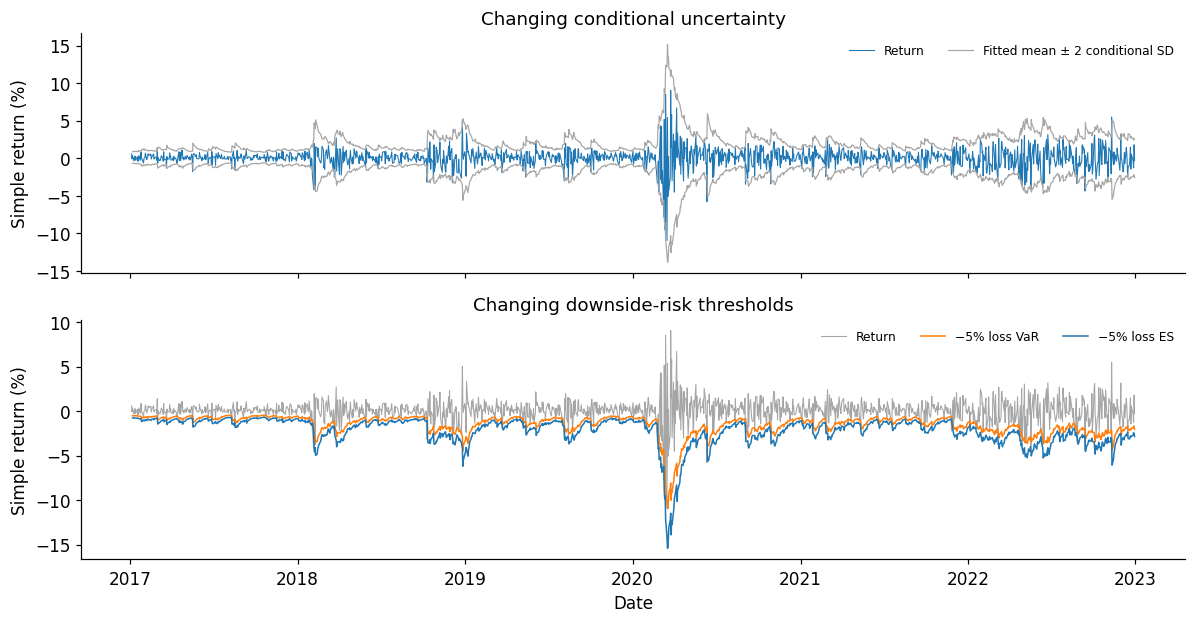

In [9]:
def conditional_loss_risk(mean, sd):
    if final_label == "Student-t":
        nu = float(final_params["nu"])
        scale = sd*np.sqrt((nu-2)/nu)
        return student_t_var(-mean,scale,nu,.05), student_t_es(-mean,scale,nu,.05)
    return gaussian_var(-mean,sd,.05), gaussian_es(-mean,sd,.05)

fitted_mean = train.to_numpy()-np.asarray(final_fit.resid)
fitted_sd = np.asarray(final_fit.conditional_volatility)
fitted_risk = np.array([conditional_loss_risk(m,s) if np.isfinite(m+s) else (np.nan,np.nan)
                        for m,s in zip(fitted_mean,fitted_sd)])
fig, axes = plt.subplots(2,1,figsize=(11,5.8),sharex=True)
axes[0].plot(train.index,train,color="C0",linewidth=.7,label="Return")
axes[0].plot(train.index,fitted_mean+2*fitted_sd,color="0.65",linewidth=.8,label="Fitted mean ± 2 conditional SD")
axes[0].plot(train.index,fitted_mean-2*fitted_sd,color="0.65",linewidth=.8)
axes[0].set(ylabel="Simple return (%)",title="Changing conditional uncertainty")
axes[1].plot(train.index,train,color="0.65",linewidth=.7,label="Return")
axes[1].plot(train.index,-fitted_risk[:,0],color="C1",linewidth=1,label="−5% loss VaR")
axes[1].plot(train.index,-fitted_risk[:,1],color="C0",linewidth=1,label="−5% loss ES")
axes[1].set(xlabel="Date",ylabel="Simple return (%)",title="Changing downside-risk thresholds")
for ax in axes: ax.legend(fontsize=8,ncol=3)
fig.tight_layout();plt.show()

## 5. Out-of-Sample Evaluation

### Return, Dispersion and Distribution

First follow the course’s forecasting setup: predict the first 24 reserved returns from one origin without using future observations. The plot combines 150 estimation observations, the conditional mean, a pointwise 95% prediction band and future observations as dots, as in Notebook 10.

The band uses 20,000 simulated histories under the selected density, rather than the course’s MSE-scaled display. Parameters are fixed; estimation uncertainty is omitted. A fixed Student-t distribution fitted to the same training returns provides the distributional baseline from Notebook 05.

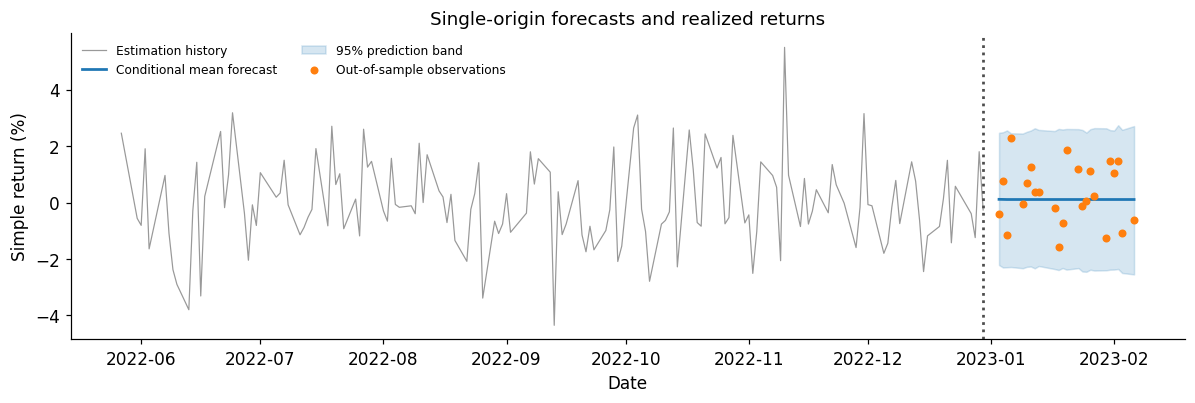

,ME (%),RMSE (%),MAE (%)
Model,,,
Conditional model,0.1867,1.0450,0.8775
Fixed Student-t,0.1965,1.0467,0.8782
Zero return,0.2940,1.0693,0.8894


Forecast conditional return SD range (%): 1.183364274349686 1.3425021462048934


In [10]:
baseline_df, baseline_mu, baseline_scale = stats.t.fit(train.to_numpy())
assert baseline_df > 2
forecast_test = test.iloc[:24]
horizon = len(forecast_test)
forecast = final_fit.forecast(horizon=horizon,reindex=False)
predicted_mean = forecast.mean.iloc[-1].to_numpy()
predicted_variance = forecast.variance.iloc[-1].to_numpy()
forecast_rng = (StudentsT(seed=1111).simulate([final_params["nu"]]) if final_label=="Student-t"
                else Normal(seed=1111).simulate([]))
paths = final_fit.forecast(horizon=horizon,method="simulation",simulations=20000,
                          reindex=False,rng=forecast_rng).simulations.values[-1]
assert paths.shape == (20000,horizon) and np.isfinite(paths).all()
lower,upper = np.quantile(paths,[.025,.975],axis=0)
fig, ax = plt.subplots(figsize=(11,3.8))
ax.plot(train.index[-150:],train.iloc[-150:],color="0.6",linewidth=.8,label="Estimation history")
ax.plot(forecast_test.index,predicted_mean,color="C0",label="Conditional mean forecast")
ax.fill_between(forecast_test.index,lower,upper,color="C0",alpha=.18,label="95% prediction band")
ax.scatter(forecast_test.index,forecast_test,color="C1",s=18,label="Out-of-sample observations",zorder=3)
ax.axvline(train.index[-1],color="0.3",linestyle=":")
ax.set(xlabel="Date",ylabel="Simple return (%)",title="Single-origin forecasts and realized returns")
ax.legend(fontsize=8,ncol=2);fig.tight_layout();plt.show()
mean_evaluation = pd.DataFrame([{"Model":label,"ME (%)":np.mean(forecast_test.to_numpy()-values),
    "RMSE (%)":forecast_rmse(forecast_test,values),"MAE (%)":forecast_mae(forecast_test,values)}
    for label,values in [("Conditional model",predicted_mean),
                         ("Fixed Student-t",np.full(horizon,baseline_mu)),("Zero return",np.zeros(horizon))]])
display(mean_evaluation.set_index("Model").round(4))
print("Forecast conditional return SD range (%):",np.sqrt(predicted_variance).min(),np.sqrt(predicted_variance).max())

### Downside Risk

The initial 24-day display illustrates forecasting; risk evaluation uses all of 2023–2025. Keep every parameter and model choice fixed at the end of 2022, then issue rolling one-step forecasts through the end of 2025. Each forecast uses only previously observed returns; observations update the mean/variance state, not the parameter estimates. The fixed Student-t baseline is unchanged. This rolling one-step exercise differs from the preceding single-origin multi-step forecast.

For VaR, compare the exceedance percentage with 5%. For ES, compare realized loss beyond each model’s threshold with its predicted tail mean. For changing thresholds, average predicted ES on the same exceedance days. This is a descriptive tail-severity comparison, not a formal ES backtest; different thresholds select different observations.

Rolling out-of-sample period: 2023-01-03–2025-12-31, n=752


,Observations,Exceedances,Exceedance (%),Target (%),Realized tail loss (%),Predicted ES on exceedance days (%)
Model,,,,,,
Fixed Student-t,752,25,3.324,5.0,2.412,3.223
Conditional model,752,55,7.314,5.0,1.697,1.685


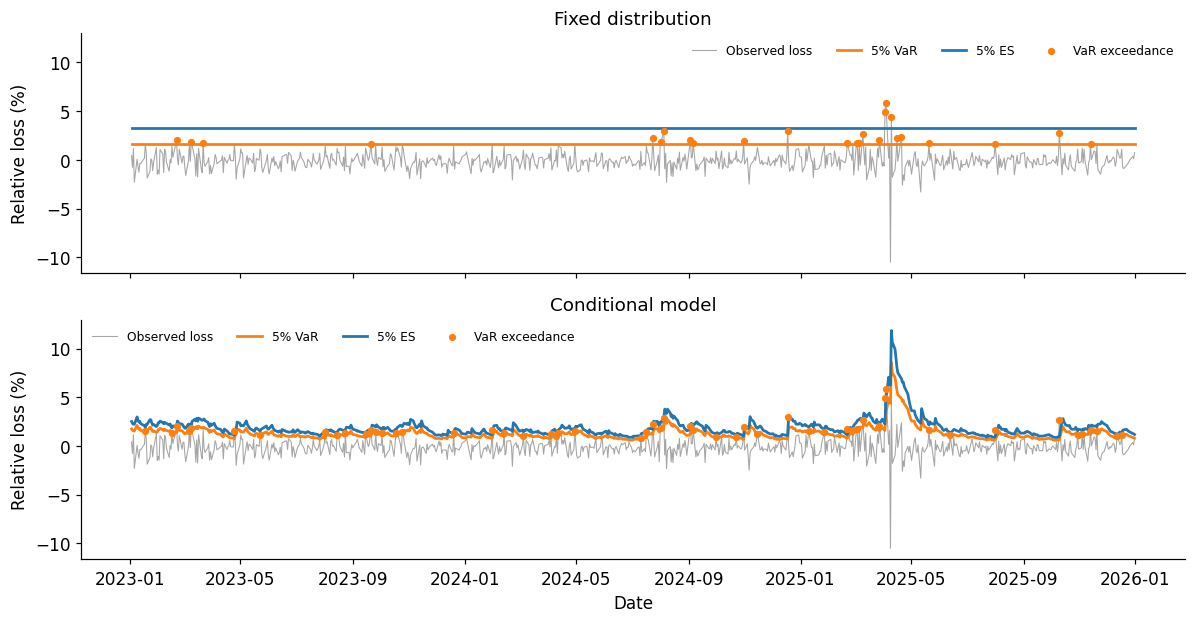

,ME (%),RMSE (%),MAE (%)
Model,,,
Conditional model,-0.0214,0.9646,0.6547
Fixed Student-t,-0.0107,0.9660,0.6535
Zero return,0.0868,0.9698,0.6608


In [11]:
extended_returns = returns
extended_test = test
print(f"Rolling out-of-sample period: {extended_test.index.min().date()}–{extended_test.index.max().date()}, n={len(extended_test)}")
mean_parameter_names = final_fit.model.parameter_names()
mean_parameters = final_params.loc[mean_parameter_names].to_numpy()
mean_intercept, mean_ar = mean_parameters[0],mean_parameters[1:]
assert len(mean_ar)==selected_p
history = list(train.to_numpy())
previous_residual = final_residuals[-1]
previous_variance = final_variances[-1]
one_step_means, one_step_variances = [],[]
for observed in extended_test.to_numpy():
    # Forecast first; the target observation has not been appended yet.
    prediction = mean_intercept+sum(coefficient*history[-lag] for lag,coefficient in enumerate(mean_ar,start=1))
    variance_prediction = garch11_forecast(previous_residual,previous_variance,omega_hat,alpha_hat,beta_hat,horizon=1)[0]
    one_step_means.append(prediction);one_step_variances.append(variance_prediction)
    # The realized target is now revealed for the NEXT forecast origin.
    previous_residual = observed-prediction
    previous_variance = variance_prediction
    history.append(observed)
one_step_means, one_step_variances = np.array(one_step_means),np.array(one_step_variances)

conditional_risk = np.array([conditional_loss_risk(m,np.sqrt(v)) for m,v in zip(one_step_means,one_step_variances)])
baseline_var = student_t_var(-baseline_mu,baseline_scale,baseline_df,.05)
baseline_es = student_t_es(-baseline_mu,baseline_scale,baseline_df,.05)
losses = -extended_test.to_numpy()
risk_rows = []
for label, var, es in [("Fixed Student-t",np.full(len(losses),baseline_var),np.full(len(losses),baseline_es)),
                       ("Conditional model",conditional_risk[:,0],conditional_risk[:,1])]:
    exceed = losses > var
    risk_rows.append({"Model":label,"Observations":len(losses),"Exceedances":int(exceed.sum()),
        "Exceedance (%)":100*exceed.mean(),"Target (%)":5.,
        "Realized tail loss (%)":losses[exceed].mean() if exceed.any() else np.nan,
        "Predicted ES on exceedance days (%)":es[exceed].mean() if exceed.any() else np.nan})
risk_evaluation = pd.DataFrame(risk_rows).set_index("Model")
display(risk_evaluation.round(3))
fig, axes = plt.subplots(2,1,figsize=(11,5.8),sharex=True,sharey=True)
for ax,label,var,es in [(axes[0],"Fixed distribution",np.full(len(losses),baseline_var),np.full(len(losses),baseline_es)),
                         (axes[1],"Conditional model",conditional_risk[:,0],conditional_risk[:,1])]:
    exceed = losses > var
    ax.plot(extended_test.index,losses,color="0.65",linewidth=.7,label="Observed loss")
    ax.plot(extended_test.index,var,color="C1",label="5% VaR")
    ax.plot(extended_test.index,es,color="C0",label="5% ES")
    ax.scatter(extended_test.index[exceed],losses[exceed],color="C1",s=14,zorder=3,label="VaR exceedance")
    ax.set(title=label,ylabel="Relative loss (%)")
    ax.legend(fontsize=8,ncol=4)
axes[-1].set_xlabel("Date");fig.tight_layout();plt.show()
# Verify that the explicit rolling recursion matches package one-step filtering.
filtered_model = arch_model(extended_returns.loc[train.index[0]:extended_test.index[-1]],
    mean="AR",lags=selected_p,vol="GARCH",p=1,q=1,
    dist="t" if final_label=="Student-t" else "normal",rescale=False,hold_back=2).fix(final_params)
origins = filtered_model.model._y_series.index.get_indexer(extended_test.index)-1
package_rolling = filtered_model.forecast(horizon=1,start=int(origins[0]),reindex=False)
np.testing.assert_allclose(one_step_means,package_rolling.mean.iloc[:len(extended_test),0],atol=1e-8)
np.testing.assert_allclose(one_step_variances,package_rolling.residual_variance.iloc[:len(extended_test),0],atol=1e-8)

rolling_mean_evaluation = pd.DataFrame([{"Model":label,"ME (%)":np.mean(extended_test.to_numpy()-values),
    "RMSE (%)":forecast_rmse(extended_test,values),"MAE (%)":forecast_mae(extended_test,values)}
    for label,values in [("Conditional model",one_step_means),
        ("Fixed Student-t",np.full(len(test),baseline_mu)),("Zero return",np.zeros(len(test)))]])
display(rolling_mean_evaluation.set_index("Model").round(4))


## 6. What Did Temporal Modeling Add?

Read the results in the same order as Notebook 05: in-sample description, estimated uncertainty, then future realizations. A better likelihood or QQ plot is evidence about the fitted sample; it does not guarantee better return forecasts or calibrated tail risk. Conditional volatility permits thresholds to respond to recent history, but that flexibility must be evaluated out of sample.

The output below summarizes this particular dataset. The short mean-forecast exercise and longer one-step risk exercise have different horizons and should not be treated as one model contest. Standardized-residual diagnostics assess remaining structure; non-rejection does not establish IID innovations. Tail averages remain based on a relatively small subset of out-of-sample observations. Univariate Student-t models can assign probability to returns below −100%; here they are approximations for daily returns, not exact support-respecting models.

The tables separate prediction accuracy, VaR frequency and tail severity. A model can improve one measure without improving all of them; conclusions should follow the out-of-sample results rather than the in-sample ranking.

For 2023–2025, the conditional model slightly reduces return RMSE (0.9646% versus 0.9660% for the fixed Student-t). Its VaR exceedance rate is 7.31%, above the 5% target, while the fixed model’s 3.32% is below it. Conditional predicted ES is close to realized tail severity on its exceedance days; the fixed model is more conservative on that comparison. These mixed results distinguish responsiveness from calibration and do not establish a universal winner.

In [12]:
print(f"Selected mean: AR({selected_p}); joint innovation distribution: {final_label}.")
print(f"Preliminary squared-residual McLeod–Li p-value (lag 20): {arch_diagnostics.iloc[-1].p_value:.4g}.")
print(f"Selected volatility persistence alpha+beta: {final_persistence:.4f}.")
for _,row in mean_evaluation.iterrows():
    print(f"Initial 24-day {row['Model']} RMSE: {row['RMSE (%)']:.4f}%.")
for label,row in risk_evaluation.iterrows():
    print(f"2023–2025 {label}: {int(row['Exceedances'])} exceedances, {row['Exceedance (%)']:.2f}% versus 5%; "
          f"realized tail loss {row['Realized tail loss (%)']:.3f}% versus predicted ES "
          f"{row['Predicted ES on exceedance days (%)']:.3f}% on those days.")
for _,row in rolling_mean_evaluation.iterrows():
    print(f"Full out-of-sample {row['Model']} RMSE: {row['RMSE (%)']:.4f}%.")


Selected mean: AR(2); joint innovation distribution: Student-t.
Preliminary squared-residual McLeod–Li p-value (lag 20): 0.
Selected volatility persistence alpha+beta: 1.0000.
Initial 24-day Conditional model RMSE: 1.0450%.
Initial 24-day Fixed Student-t RMSE: 1.0467%.
Initial 24-day Zero return RMSE: 1.0693%.
2023–2025 Fixed Student-t: 25 exceedances, 3.32% versus 5%; realized tail loss 2.412% versus predicted ES 3.223% on those days.
2023–2025 Conditional model: 55 exceedances, 7.31% versus 5%; realized tail loss 1.697% versus predicted ES 1.685% on those days.
Full out-of-sample Conditional model RMSE: 0.9646%.
Full out-of-sample Fixed Student-t RMSE: 0.9660%.
Full out-of-sample Zero return RMSE: 0.9698%.
